# Chapter 23 — Wired Industrial Communication Protocols: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks at the end of each section. All exercises run in Google
> Colab with no additional hardware, network connection, or industrial
> equipment — every exercise is a self-contained simulation built directly
> from the published wire-format and timing rules of each protocol.

| Exercise | Topic | Key technique |
|----------|-------|----------------|
| 23.1 | Modbus RTU vs. Modbus TCP | Byte-exact frame/CRC encoder across three protocol-stack levels; serial vs. Ethernet polling timing |
| 23.2 | OPC UA vs. Modbus | Binary encoding size (IEC 62541-6); block vs. scattered Modbus reads; report-by-exception with named Subscription parameters |
| 23.3 | EtherNet/IP vs. PROFINET RT/IRT | Exact M/M/1 queueing simulation of four industrial real-time configurations |
| 23.4 | Wired vs. wireless IIoT | Total-cost-of-ownership and reliability decision framework |


---
## Setup

In [1]:
# -- Setup --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 1.7,
})

---
## Exercise 23.1 — Modbus RTU vs. Modbus TCP: Frame Overhead Across Protocol-Stack Levels, and Serial Polling-Cycle Time

### Background

Modbus is one of the oldest and still one of the most widely deployed
industrial protocols in this chapter, and it exists in two wire-level
forms that are functionally equivalent but structurally different:
**Modbus RTU**, a compact binary frame carried directly over an RS-485
multi-drop serial line, and **Modbus TCP**, the same Protocol Data Unit
(PDU) wrapped in a small MBAP (Modbus Application Protocol) header and
carried over ordinary
TCP/IP. This exercise builds byte-exact encoders for both, validates the
RTU CRC-16 error-detection field against the worked example published in
the specification, and then compares the two at **three different levels
of the protocol stack** — a distinction that turns out to matter a great
deal for what "TCP is more efficient" actually means.

### Modbus-layer frame formats

For a Read Holding Registers request (function code 0x03), a Modbus RTU
frame is `Address(1) + FunctionCode(1) + StartAddr(2) + Quantity(2) +
CRC(2)` = 8 bytes for the request, and `Address(1) + FunctionCode(1) +
ByteCount(1) + Data(2*Qty) + CRC(2)` for the response. Modbus TCP drops
the address byte and the CRC — TCP already guarantees ordered,
error-checked, in-sequence delivery — and instead prepends a fixed
7-byte MBAP header (2-byte Transaction ID, 2-byte Protocol ID, 2-byte
Length, 1-byte Unit ID) to the same function-code-plus-data PDU. Because
the 7-byte MBAP header is *larger* than the 3 bytes RTU spends on address
and CRC combined, **Modbus TCP frames are always a few bytes larger than
the equivalent RTU frames at the Modbus layer** — a small, constant gap
that has nothing to do with efficiency and everything to do with which
fields each framing method needs.

In [2]:
# -- Exercise 23.1: byte-exact frame encoders and CRC-16 -----------------
def modbus_crc16(data: bytes) -> int:
    '''Modbus CRC-16: polynomial 0xA001, initial register 0xFFFF.'''
    crc = 0xFFFF
    for b in data:
        crc ^= b
        for _ in range(8):
            crc = (crc >> 1) ^ 0xA001 if crc & 1 else crc >> 1
    return crc

def crc_bytes(data: bytes) -> bytes:
    crc = modbus_crc16(data)
    return bytes([crc & 0xFF, (crc >> 8) & 0xFF])   # low byte first, per spec

# PRIMARY self-test: the worked CRC example actually printed in the Modbus
# over Serial Line specification (Sec. "Example of CRC calculation", frame 02 07):
primary_vector = bytes([0x02, 0x07])
print("Spec-worked example  02 07        -> CRC", crc_bytes(primary_vector).hex(), "(spec gives 4112)")
assert crc_bytes(primary_vector).hex() == "4112"

# SECONDARY, independent self-consistency check on a longer frame (not claimed
# to be a published worked example -- just a second check of the algorithm):
secondary_vector = bytes([0x11, 0x03, 0x00, 0x6B, 0x00, 0x03])
print("Independent check    11 03 00 6B 00 03 -> CRC", crc_bytes(secondary_vector).hex())

def rtu_request_bytes():
    return 1 + 1 + 2 + 2 + 2                       # addr, fc, start, qty, crc

def rtu_response_bytes(qty):
    return 1 + 1 + 1 + 2*qty + 2                   # addr, fc, bytecount, data, crc

MBAP = 7                                            # transaction(2)+protocol(2)+length(2)+unit(1)

def tcp_request_bytes():
    return MBAP + (1 + 2 + 2)                       # fc, start, qty

def tcp_response_bytes(qty):
    return MBAP + (1 + 1 + 2*qty)                   # fc, bytecount, data

qtys = np.arange(1, 126)
rtu_total = rtu_request_bytes() + np.array([rtu_response_bytes(q) for q in qtys])
tcp_total = tcp_request_bytes() + np.array([tcp_response_bytes(q) for q in qtys])
payload_bytes = 2*qtys

rtu_overhead_frac = 1 - payload_bytes/rtu_total
tcp_overhead_frac = 1 - payload_bytes/tcp_total

print("\nModbus-layer bytes (request+response):")
for q in [1, 10, 125]:
    i = q-1
    print(f"  qty={q:3d}: RTU={rtu_total[i]:3d} B   TCP={tcp_total[i]:3d} B   "
          f"(TCP is {tcp_total[i]-rtu_total[i]} B larger, always)")
print(f"\nOverhead fraction at qty=10: RTU={rtu_overhead_frac[9]*100:.1f}%   TCP={tcp_overhead_frac[9]*100:.1f}%"
      f"  -- TCP's overhead fraction is higher, not lower, at every read size.")

Spec-worked example  02 07        -> CRC 4112 (spec gives 4112)
Independent check    11 03 00 6B 00 03 -> CRC 7687

Modbus-layer bytes (request+response):
  qty=  1: RTU= 15 B   TCP= 23 B   (TCP is 8 B larger, always)
  qty= 10: RTU= 33 B   TCP= 41 B   (TCP is 8 B larger, always)
  qty=125: RTU=263 B   TCP=271 B   (TCP is 8 B larger, always)

Overhead fraction at qty=10: RTU=39.4%   TCP=51.2%  -- TCP's overhead fraction is higher, not lower, at every read size.


In [3]:
# -- Exercise 23.1: adding the wire-level (TCP/IP + Ethernet) picture ----
# Modbus RTU is carried directly on the serial wire: the byte counts above
# ARE the wire-level cost (UART start/stop/parity bits are a separate,
# bit-level cost captured later in the timing model, not additional bytes).
# Modbus TCP, by contrast, is normally carried inside a full TCP/IP/Ethernet
# stack, which adds substantial framing the Modbus-layer count above omits.
TCPIP_MIN = 40        # IPv4 (20 B) + TCP (20 B), no options
ETH_FRAME = 14 + 4     # Ethernet header (14 B) + FCS (4 B); preamble/SFD excluded (physical layer only)

def tcp_wire_bytes(qty):
    req_wire  = tcp_request_bytes()          + TCPIP_MIN + ETH_FRAME
    resp_wire = tcp_response_bytes(qty)      + TCPIP_MIN + ETH_FRAME
    return req_wire + resp_wire

qty_demo = 10
rtu_demo        = rtu_request_bytes() + rtu_response_bytes(qty_demo)
tcp_modbus_demo = tcp_request_bytes() + tcp_response_bytes(qty_demo)
tcp_wire_demo   = tcp_wire_bytes(qty_demo)

print(f"At a 10-register read, three protocol-stack levels:")
print(f"  RTU, serial wire                          : {rtu_demo:4d} B")
print(f"  TCP, Modbus (MBAP) layer only              : {tcp_modbus_demo:4d} B")
print(f"  TCP, minimum Ethernet-frame-level incl. TCP/IP+Eth. : {tcp_wire_demo:4d} B  "
      f"({tcp_wire_demo/rtu_demo:.1f}x the RTU wire cost)")

At a 10-register read, three protocol-stack levels:
  RTU, serial wire                          :   33 B
  TCP, Modbus (MBAP) layer only              :   41 B
  TCP, minimum Ethernet-frame-level incl. TCP/IP+Eth. :  157 B  (4.8x the RTU wire cost)


In [4]:
# -- Exercise 23.1: serial (RTU) vs. Ethernet (TCP) polling-cycle timing --
BITS_PER_CHAR = 11   # 1 start + 8 data + 1 parity + 1 stop (Modbus RTU default: even parity)

def char_time(baud):
    return BITS_PER_CHAR / baud

def inter_frame_gap(baud):
    '''Modbus over Serial Line V1.02: for baud rates above 19200 the 1.5- and
    3.5-character silent intervals are FIXED at 750 us and 1750 us, rather
    than continuing to shrink with baud.'''
    if baud > 19200:
        return 750e-6, 1750e-6
    ct = char_time(baud)
    return 1.5*ct, 3.5*ct

def rtu_cycle_time(N, baud, qty, turnaround_s):
    ct = char_time(baud)
    _, t35 = inter_frame_gap(baud)
    req_time  = rtu_request_bytes()      * ct
    resp_time = rtu_response_bytes(qty)  * ct
    per_device = t35 + req_time + turnaround_s + resp_time
    return N * per_device

def tcp_cycle_time(N, rtt_s, turnaround_s, parallel=False, max_parallel=8):
    per_device = rtt_s + turnaround_s
    if not parallel:
        return N * per_device
    rounds = int(np.ceil(N / max_parallel))
    return rounds * per_device

baud_rates = [9600, 19200, 115200]
N_range    = np.arange(1, 65)
qty_poll   = 10
turnaround = 5e-3        # ASSUMPTION: representative slave processing/turnaround delay
rtt_lan    = 1e-3        # ASSUMPTION: representative switched-LAN round-trip time

rtu_cycles = {b: np.array([rtu_cycle_time(N, b, qty_poll, turnaround) for N in N_range]) for b in baud_rates}
tcp_seq  = np.array([tcp_cycle_time(N, rtt_lan, turnaround, parallel=False) for N in N_range])
tcp_par8 = np.array([tcp_cycle_time(N, rtt_lan, turnaround, parallel=True, max_parallel=8) for N in N_range])

print("Full polling-cycle time at N = 32 devices, 10 registers each:")
for b in baud_rates:
    print(f"  RTU @ {b:>6} baud : {rtu_cycles[b][31]*1000:7.1f} ms")
print(f"  TCP, sequential  : {tcp_seq[31]*1000:7.1f} ms")
print(f"  TCP, 8-way parallel: {tcp_par8[31]*1000:7.1f} ms")

Full polling-cycle time at N = 32 devices, 10 registers each:
  RTU @   9600 baud :  1498.3 ms
  RTU @  19200 baud :   829.2 ms
  RTU @ 115200 baud :   316.8 ms
  TCP, sequential  :   192.0 ms
  TCP, 8-way parallel:    24.0 ms


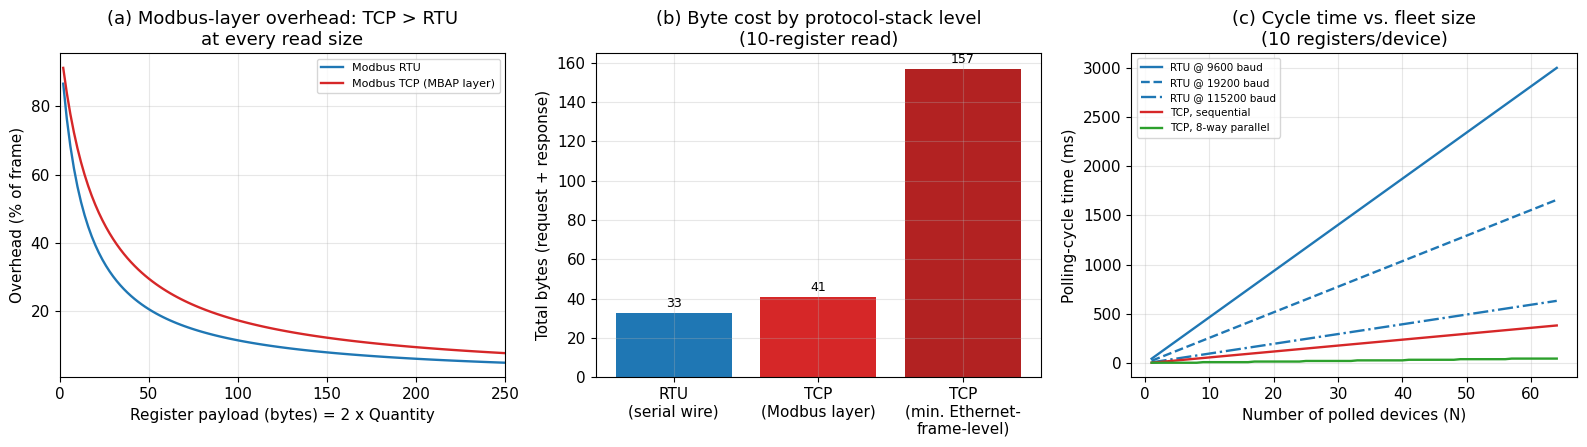

In [5]:
# -- Figure 23.1: three-level byte cost, and polling-cycle time ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
ax.plot(payload_bytes, rtu_overhead_frac*100, color='tab:blue', label='Modbus RTU')
ax.plot(payload_bytes, tcp_overhead_frac*100, color='tab:red',  label='Modbus TCP (MBAP layer)')
ax.set_xlabel('Register payload (bytes) = 2 x Quantity')
ax.set_ylabel('Overhead (% of frame)')
ax.set_title('(a) Modbus-layer overhead: TCP > RTU\nat every read size')
ax.legend(fontsize=8)
ax.set_xlim(0, 250)

ax = axes[1]
bars = ['RTU\n(serial wire)', 'TCP\n(Modbus layer)', 'TCP\n(min. Ethernet-\nframe-level)']
vals = [rtu_demo, tcp_modbus_demo, tcp_wire_demo]
bars_obj = ax.bar(bars, vals, color=['tab:blue', 'tab:red', 'firebrick'])
for b, v in zip(bars_obj, vals):
    ax.text(b.get_x()+b.get_width()/2, v+3, str(v), ha='center', fontsize=9)
ax.set_ylabel('Total bytes (request + response)')
ax.set_title('(b) Byte cost by protocol-stack level\n(10-register read)')

ax = axes[2]
for b, style in zip(baud_rates, ['-', '--', '-.']):
    ax.plot(N_range, rtu_cycles[b]*1000, style, color='tab:blue', label=f'RTU @ {b} baud')
ax.plot(N_range, tcp_seq*1000,  color='tab:red',   label='TCP, sequential')
ax.plot(N_range, tcp_par8*1000, color='tab:green', label='TCP, 8-way parallel')
ax.set_xlabel('Number of polled devices (N)')
ax.set_ylabel('Polling-cycle time (ms)')
ax.set_title('(c) Cycle time vs. fleet size\n(10 registers/device)')
ax.legend(fontsize=7.5)

plt.tight_layout()
plt.show()

### Analysis

**Figure 23.1(a)** and the printed byte counts above establish something
that is easy to get backwards: at the Modbus application layer, **TCP
frames are never smaller than RTU frames for the same read** — the
7-byte MBAP header costs more than the 3 bytes RTU spends on its address
byte and CRC combined, so TCP is a constant 8 bytes larger (request plus
response) at every read size, and its overhead *fraction* is
correspondingly higher throughout, not lower. This gap shrinks in
*relative* terms as the payload grows (both curves approach 0% overhead
asymptotically), but TCP's curve never crosses below RTU's.

**Figure 23.1(b)** completes the picture by adding the transport layer
Modbus RTU is compared against implicitly but TCP is not: a real Modbus
TCP exchange normally travels inside TCP/IP over Ethernet, adding roughly
108 bytes of TCP/IP-and-Ethernet framing across the request/response pair
on top of the Modbus-layer bytes already counted. This minimum
Ethernet-frame-level estimate (Ethernet header/FCS plus a minimum
IPv4/TCP header on each direction; it still excludes preamble/SFD, the
inter-frame gap, TCP options, ACK-only frames, and retransmissions, so
it is a lower bound on real traffic) already puts a 10-register TCP
exchange at **157 bytes against RTU's 33** — nearly five times as much,
not less.

None of this means Modbus TCP is a poor choice; it means the reason to
choose it is not frame size. **Figure 23.1(c)** shows the reason that
matters most in this model: on a shared RS-485 multi-drop line, every
device must be polled *sequentially*, and the mandatory 3.5-character
silent interval between frames means a master cannot overlap requests
to different devices. At 9600 baud, polling 32 devices for 10 registers
each already takes 1.5 seconds; even at 115200 baud it takes over
300 ms. Modbus TCP over switched Ethernet removes that shared-medium
constraint entirely: each device has its own point-to-point connection,
so a master issuing requests in parallel (here, 8 at a time) collapses
the same 32-device cycle to roughly 24 ms — close to a 60-fold
improvement over 9600-baud RTU, achieved *despite* every individual TCP
exchange costing more bytes than its RTU equivalent. A real deployment
gains further practical advantages from switched Ethernet — routability,
higher link bandwidth, easier IT integration, remote diagnostics — that
this timing model does not attempt to quantify.

> **Key takeaway.** Modbus TCP's advantage over Modbus RTU has nothing to
> do with frame size — TCP frames are consistently larger at every
> protocol-stack level examined here, from the Modbus layer alone up to
> the minimum-Ethernet-frame-level estimate. In this model, the dominant
> timing advantage instead comes from eliminating the single
> shared-medium serial bottleneck and allowing parallel transactions:
> on a large fleet, polling-cycle time — not frame overhead — is what
> actually limits how many devices a Modbus network can support at a
> given update rate.

### Challenge tasks

1. Recompute Figure 23.1(b) for a *write* operation (function code 0x10,
   Write Multiple Registers) instead of a read, at both the Modbus layer
   and the minimum-Ethernet-frame-level estimate. Does the RTU/TCP byte gap grow, shrink, or
   stay roughly the same?
2. Real RS-485 networks are sometimes split into multiple segments with
   repeaters once electrical loading limits are reached. Extend the RTU
   model to allow up to 4 independent serial segments polled in parallel
   by the same master, and compare the resulting cycle time at N=64
   devices against Ethernet/TCP with 8-way parallelism.
3. The turnaround delay was fixed at 5 ms. Sweep it from 1 ms to 20 ms
   and identify the value at which RTU (115200 baud) and sequential
   Modbus TCP cross over in cycle time at N=32.
4. `TCPIP_MIN` assumed no TCP options. Recompute the wire-level bar chart
   using the 52-byte "typical, including common options" figure often
   quoted for real-world TCP/IP headers instead of the 40-byte minimum.
   How much does this change the RTU-vs-TCP wire-level ratio?

---
## Exercise 23.2 — OPC UA vs. Modbus: Semantic Overhead and the Report-by-Exception Advantage

### Background

Where Modbus exposes only anonymous numbered registers, OPC UA exposes
a typed, self-describing information model, and that expressiveness has
a byte cost. This exercise quantifies it two ways: first, the raw
transaction size of an OPC UA `Read` service call versus an equivalent
Modbus register read; second, the very different way each protocol
behaves *over time* — Modbus is exclusively a polling protocol, while
OPC UA's Subscription mechanism can report a value only when it
actually changes.

**A note on what is, and is not, being modelled — and on a
methodological trap worth naming explicitly.** The OPC UA byte counts
below are a **representative OPC UA Binary service-layer estimate**,
built from the field list in IEC 62541 Parts 4 and 6 with a stated,
explicit set of fields included (`RequestHeader`/`ResponseHeader`,
`MaxAge`, `TimestampsToReturn`, array-length fields, `ReadValueId`,
`DataValue`/`Variant` encoding) and a stated set excluded (UA Secure
Conversation framing, message chunking, security headers). Comparing
that service-layer estimate against a *single* Modbus number invites a
mismatch: Modbus can be counted at (at least) three different levels —
the bare **PDU** (function code and data only, no addressing or
error-checking), the **RTU ADU** (PDU plus slave address and CRC, the
form actually carried on an RS-485 wire), or the **TCP ADU** (PDU plus
the MBAP header). These three levels differ by roughly 2.5x at the same
poll rate, and **which one is chosen changes whether OPC UA looks
cheaper or more expensive than Modbus** — a crossover that is a
property of the accounting boundary chosen, not a fixed fact about the
two protocols. This exercise makes all three levels explicit rather
than picking one silently.

A second point: **OPC UA's Subscription mechanism is bidirectional.** A
server does not push notifications or keep-alives unprompted — it
answers a `PublishRequest` the client has already queued, and in
steady-state operation the client must keep sending new
`PublishRequest` messages to replenish that queue, essentially one for
every `PublishResponse` it receives. Counting only server-to-client
traffic understates OPC UA's real cost.

In [6]:
# -- Exercise 23.2: OPC UA Binary Read service sizing (representative) ---
VARIANT_INT16 = 1 + 2
def datavalue_bytes(with_status=True, with_src_ts=True, with_srv_ts=True):
    b = 1 + VARIANT_INT16
    if with_status: b += 4
    if with_src_ts: b += 8
    if with_srv_ts: b += 8
    return b

DV_MIN  = datavalue_bytes(False, False, False)
DV_FULL = datavalue_bytes(True, True, True)       # value+status+both timestamps, excl. picoseconds
print(f"DataValue size: minimal = {DV_MIN} B,  value+status+both timestamps (excl. picoseconds) = {DV_FULL} B")

NODEID_4B          = 4
READVALUEID_BYTES  = NODEID_4B + 4 + 4 + 6
REQUEST_HEADER     = 26
RESPONSE_HEADER    = 20
MAX_AGE            = 8
TIMESTAMPS_TO_RET  = 4
ARRAY_LEN          = 4
PUBLISH_OVERHEAD   = 46
PUBLISH_REQ_BASE   = REQUEST_HEADER + ARRAY_LEN
ACK_BYTES          = 8
CLIENT_HANDLE      = 4

# -- THREE explicitly-labelled Modbus accounting levels (same qty) -------
def modbus_pdu_bytes(qty=1):
    '''PDU only: function code + data, no address, no CRC, no MBAP.'''
    req_pdu  = 1+2+2            # fc, start, qty
    resp_pdu = 1+1+2*qty        # fc, bytecount, data
    return req_pdu + resp_pdu

def modbus_rtu_adu_bytes(qty=1):
    '''RTU ADU: what is actually carried on an RS-485 wire.'''
    req  = 1+1+2+2+2            # addr, fc, start, qty, crc
    resp = 1+1+1+2*qty+2        # addr, fc, bytecount, data, crc
    return req + resp

def modbus_tcp_adu_bytes(qty=1):
    '''TCP ADU: PDU plus the 7-byte MBAP header (Exercise 23.1's Modbus-layer level).'''
    MBAP = 7
    req  = MBAP + 1+2+2
    resp = MBAP + 1+1+2*qty
    return req + resp

def modbus_block_read_bytes(n_tags):
    return modbus_rtu_adu_bytes(qty=n_tags)

def modbus_scattered_bytes(n_tags):
    return modbus_rtu_adu_bytes(qty=1) * n_tags

def opcua_read_bytes(n_tags=1):
    req  = REQUEST_HEADER + MAX_AGE + TIMESTAMPS_TO_RET + ARRAY_LEN + n_tags*READVALUEID_BYTES
    resp = RESPONSE_HEADER + ARRAY_LEN + n_tags*DV_FULL + ARRAY_LEN
    return req + resp

for name, fn in [('Modbus PDU', modbus_pdu_bytes), ('Modbus RTU ADU', modbus_rtu_adu_bytes),
                  ('Modbus TCP ADU', modbus_tcp_adu_bytes)]:
    b = fn(1)
    print(f"{name:16s}: {b:3d} B/poll  ->  {b*1440/1024:6.1f} KB/day at a 60 s poll rate")

n_tags_range = np.arange(1, 51)
modbus_block_arr     = np.array([modbus_block_read_bytes(n) for n in n_tags_range])
modbus_scattered_arr = np.array([modbus_scattered_bytes(n)  for n in n_tags_range])
opcua_batch_arr      = np.array([opcua_read_bytes(n)        for n in n_tags_range])
print(f"\nAt 20 tags: Modbus RTU ADU block-read={modbus_block_arr[19]} B   "
      f"scattered={modbus_scattered_arr[19]} B   OPC UA batched Read={opcua_batch_arr[19]} B")

DataValue size: minimal = 4 B,  value+status+both timestamps (excl. picoseconds) = 24 B
Modbus PDU      :   9 B/poll  ->    12.7 KB/day at a 60 s poll rate
Modbus RTU ADU  :  15 B/poll  ->    21.1 KB/day at a 60 s poll rate
Modbus TCP ADU  :  23 B/poll  ->    32.3 KB/day at a 60 s poll rate

At 20 tags: Modbus RTU ADU block-read=53 B   scattered=300 B   OPC UA batched Read=910 B


In [7]:
# -- Exercise 23.2: report-by-exception, bidirectional, THREE Modbus levels
rng = np.random.default_rng(42)
duration_s = 24*3600
sample_dt  = 2.0
t = np.arange(0, duration_s, sample_dt)

signal = 21.0 + 2.0*np.sin(2*np.pi*t/duration_s - np.pi/2) + rng.normal(0, 0.03, size=t.size)
signal[(t > 6*3600)  & (t < 6.2*3600)]  += 1.2
signal[(t > 15*3600) & (t < 15.3*3600)] -= 0.9

def modbus_polling_bytes(poll_interval_s, level_fn=modbus_rtu_adu_bytes):
    n_polls = int(duration_s / poll_interval_s)
    return n_polls * level_fn(1), n_polls

def opcua_subscription_bytes(deadband, publishing_interval_s=2.0, max_keepalive_count=30):
    '''Returns (server_to_client_bytes, client_to_server_bytes, n_notifications, n_keepalives).'''
    keepalive_interval_s = publishing_interval_s * max_keepalive_count
    idx_step = max(1, int(round(publishing_interval_s/sample_dt)))
    sampled = signal[::idx_step]
    last_reported, last_report_time = sampled[0], 0.0
    n_notifications, n_keepalives = 1, 0
    s2c = PUBLISH_OVERHEAD + CLIENT_HANDLE + DV_FULL
    c2s = PUBLISH_REQ_BASE
    for k in range(1, len(sampled)):
        now = k*idx_step*sample_dt
        if abs(sampled[k]-last_reported) > deadband:
            s2c += PUBLISH_OVERHEAD + CLIENT_HANDLE + DV_FULL
            c2s += PUBLISH_REQ_BASE + ACK_BYTES
            n_notifications += 1
            last_reported, last_report_time = sampled[k], now
        elif now - last_report_time >= keepalive_interval_s:
            s2c += PUBLISH_OVERHEAD
            c2s += PUBLISH_REQ_BASE
            n_keepalives += 1
            last_report_time = now
    return s2c, c2s, n_notifications, n_keepalives

deadbands = np.array([0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5])
poll_rates_shown = [10, 60]
levels = [('Modbus PDU', modbus_pdu_bytes), ('Modbus RTU ADU', modbus_rtu_adu_bytes), ('Modbus TCP ADU', modbus_tcp_adu_bytes)]

print("Modbus daily traffic, all three accounting levels:")
for pr in poll_rates_shown:
    row = [modbus_polling_bytes(pr, fn)[0]/1024 for _, fn in levels]
    print(f"  poll/{pr:>2}s: PDU={row[0]:6.1f}  RTU-ADU={row[1]:6.1f}  TCP-ADU={row[2]:6.1f}  KB/day")

print("\nOPC UA daily bidirectional traffic at db=0.20 C:")
for ka_count, label in [(30, '60 s'), (150, '300 s'), (300, '600 s')]:
    s2c, c2s, n, ka = opcua_subscription_bytes(0.20, 2.0, ka_count)
    print(f"  keep-alive {label:>5}: s2c={s2c/1024:6.1f}  c2s={c2s/1024:6.1f}  TOTAL={( s2c+c2s)/1024:6.1f} KB/day")

Modbus daily traffic, all three accounting levels:
  poll/10s: PDU=  75.9  RTU-ADU= 126.6  TCP-ADU= 194.1  KB/day
  poll/60s: PDU=  12.7  RTU-ADU=  21.1  TCP-ADU=  32.3  KB/day

OPC UA daily bidirectional traffic at db=0.20 C:
  keep-alive  60 s: s2c=  66.8  c2s=  43.1  TOTAL= 110.0 KB/day
  keep-alive 300 s: s2c=  15.1  c2s=   9.4  TOTAL=  24.5 KB/day
  keep-alive 600 s: s2c=   8.7  c2s=   5.2  TOTAL=  13.9 KB/day


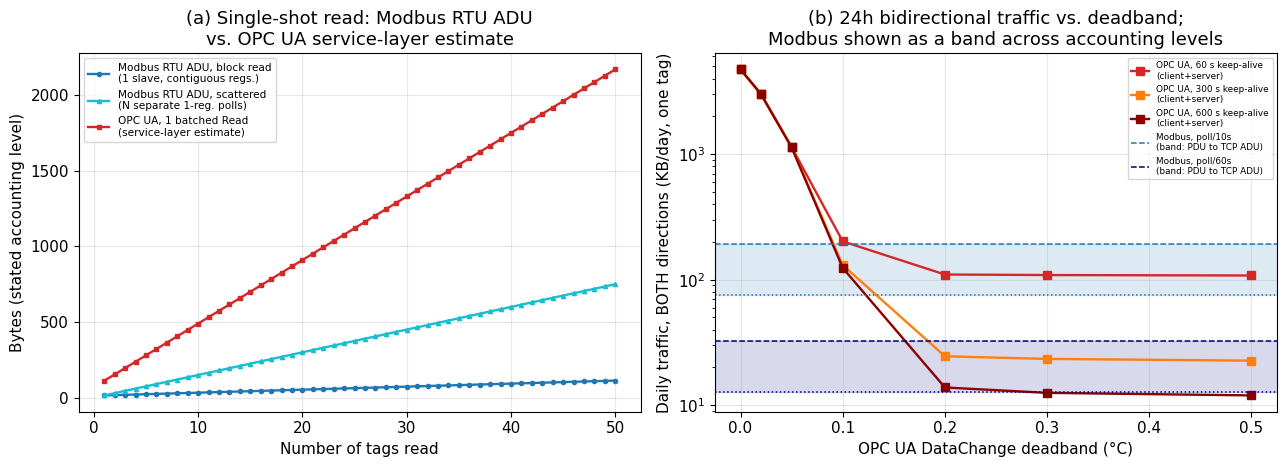

In [8]:
# -- Figure 23.2: single-shot read, and 24h traffic with Modbus shown as -
# a BAND across accounting levels rather than a single line -- this is
# the direct fix for comparing OPC UA against one arbitrarily-chosen
# Modbus level.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.plot(n_tags_range, modbus_block_arr, color='tab:blue', marker='o', ms=3,
        label='Modbus RTU ADU, block read\n(1 slave, contiguous regs.)')
ax.plot(n_tags_range, modbus_scattered_arr, color='tab:cyan', marker='^', ms=3,
        label='Modbus RTU ADU, scattered\n(N separate 1-reg. polls)')
ax.plot(n_tags_range, opcua_batch_arr, color='tab:red', marker='s', ms=3,
        label='OPC UA, 1 batched Read\n(service-layer estimate)')
ax.set_xlabel('Number of tags read')
ax.set_ylabel('Bytes (stated accounting level)')
ax.set_title('(a) Single-shot read: Modbus RTU ADU\nvs. OPC UA service-layer estimate')
ax.legend(fontsize=7.6)

ax = axes[1]
ka_settings = [(30, '60 s keep-alive'), (150, '300 s keep-alive'), (300, '600 s keep-alive')]
colors_ka = ['tab:red', 'tab:orange', 'darkred']
for (ka_count, lbl), c in zip(ka_settings, colors_ka):
    vals = np.array([sum(opcua_subscription_bytes(db, 2.0, ka_count)[:2]) for db in deadbands])
    ax.plot(deadbands, vals/1024, color=c, marker='s', label=f'OPC UA, {lbl}\n(client+server)')
band_colors = {10: 'tab:blue', 60: 'navy'}
for pr in poll_rates_shown:
    row = [modbus_polling_bytes(pr, fn)[0] for _, fn in levels]
    lo, hi = min(row), max(row)
    ax.axhspan(lo/1024, hi/1024, color=band_colors[pr], alpha=0.15)
    ax.axhline(lo/1024, color=band_colors[pr], ls=':', lw=1.1)
    ax.axhline(hi/1024, color=band_colors[pr], ls='--', lw=1.1,
               label=f'Modbus, poll/{pr}s\n(band: PDU to TCP ADU)')
ax.set_xlabel('OPC UA DataChange deadband (\u00b0C)')
ax.set_ylabel('Daily traffic, BOTH directions (KB/day, one tag)')
ax.set_title('(b) 24h bidirectional traffic vs. deadband;\nModbus shown as a band across accounting levels')
ax.legend(fontsize=6.4, ncol=1, loc='upper right')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

### Analysis

**Figure 23.2(a)** shows why the two Modbus scenarios matter. For
contiguous registers on one device, Modbus's RTU-ADU block read scales
gracefully and stays well below OPC UA's batched Read at every tag
count. Once the tags are scattered, Modbus's cost grows far faster,
though it still remains below OPC UA's single batched exchange at the
tag counts examined here.

**Figure 23.2(b)** shows why the choice of Modbus accounting level
matters as much as it does. Modbus can be measured at three
different, individually legitimate levels — bare PDU, RTU ADU (the wire
form), or TCP ADU — and at a 60-second poll rate these differ by more
than 2.5x (12.7 / 21.1 / 32.3 KB/day). OPC UA's daily bidirectional
total at a 0.2°C deadband and a 300-second keep-alive (24.5 KB/day)
lands *inside* that spread: slightly above the RTU-ADU figure, but
comfortably below the TCP-ADU figure. At a 600-second keep-alive
(13.9 KB/day), OPC UA beats the RTU-ADU and TCP-ADU levels but is still
close to, and at higher poll rates can exceed, the bare-PDU level.
**The crossover between OPC UA and Modbus is therefore not a fixed
property of the two protocols — it is a property of which Modbus
accounting boundary and which OPC UA keep-alive setting are being
compared.** A claim that "OPC UA beats Modbus" or "Modbus beats OPC UA"
is incomplete without stating both.

The more general, more defensible conclusion is this: OPC UA's
report-by-exception mechanism has to work harder
than a first look suggests — a competitive keep-alive setting is
measured in minutes, not tens of seconds — but once configured
appropriately, it lands in the same broad traffic range as Modbus
polling across all three accounting levels, which is a legitimately
useful result even without a single crisp "winner."

> **Key takeaway.** A bandwidth comparison between two protocols is
> only as meaningful as the accounting boundary each side is measured
> at. Modbus alone spans a 2.5x range depending on whether you count
> the bare PDU, the RTU wire ADU, or the TCP ADU; OPC UA's bidirectional
> Subscription traffic spans a comparable range depending on the
> keep-alive interval chosen. Reporting a single "OPC UA is N% smaller
> than Modbus" number without stating both accounting choices is not
> wrong so much as underspecified — and different, equally reasonable
> choices can flip the sign of the comparison.

### Challenge tasks

1. `PublishRequest` traffic assumed one request per response, with at
   most one `SubscriptionAcknowledgement`. Real clients sometimes batch
   several pending acknowledgements into a single request rather than
   sending one request per response. Extend the model to include
   several outstanding `PublishRequest`s and batched sequence-number
   acknowledgements — and account for **both** sides of that change:
   the acknowledgement entries added to each `PublishRequest`, and the
   corresponding result entries OPC UA's `PublishResponse.Results[]`
   array must carry for each one, which the single-request model above
   does not include.
2. Recompute the crossover keep-alive interval (the value at which OPC
   UA's bidirectional total first drops below a given Modbus accounting
   level) analytically, as a function of both deadband and the chosen
   Modbus level, and compare it against the values this exercise found
   by simulation.
3. Repeat the 24-hour comparison for a noisier signal (e.g. vibration).
   Does the band-versus-band picture in Figure 23.2(b) still show
   meaningful overlap, or does OPC UA fall outside the Modbus band
   entirely at every keep-alive setting tested?
4. Research the role of OPC UA's `LifetimeCount` parameter (distinct
   from `MaxKeepAliveCount`), which determines when an unacknowledged
   Subscription is deleted by the server, and discuss what failure mode
   it protects against that keep-alive alone does not.

---
## Exercise 23.3 — EtherNet/IP vs. PROFINET RT/IRT: Cyclic-I/O Queueing Delay and Determinism

### Background

Both EtherNet/IP (built on CIP, the Common Industrial Protocol) and
PROFINET run cyclic I/O over ordinary switched Ethernet, but they offer
different mechanisms for sharing that Ethernet segment with other
traffic, and — importantly — different *defaults*.

- **EtherNet/IP, unconfigured**: implicit (I/O) messaging sent at a
  configured Requested Packet Interval with no special queueing
  priority. Priority treatment cannot be assumed for a generic,
  unconfigured EtherNet/IP implicit I/O connection — an I/O frame then
  waits in the same best-effort switch egress queue as everything else.
- **EtherNet/IP, with CIP QoS**: ODVA defines a QoS Object that can mark
  CIP traffic with IEEE 802.1Q/802.1D priority tags and/or DSCP values,
  giving I/O traffic a separate, higher-priority queue. This mechanism
  exists and is used in real deployments, and carries particular
  normative weight for latency-sensitive CIP profiles such as CIP
  Motion and CIP Sync; it simply cannot be assumed active unless
  specifically configured or required by the applicable profile.
- **PROFINET RT** (Real-Time): tags its frames with IEEE 802.1Q VLAN
  priority 6 and uses a dedicated EtherType (0x8892) that lets
  RT-capable devices bypass the normal TCP/IP processing path
  entirely, so switches serve RT frames from a separate,
  higher-priority queue ahead of best-effort traffic.
- **PROFINET IRT** (Isochronous Real-Time): reserves fixed,
  clock-synchronised time slots for RT traffic within every cycle
  (cycle times down to 31.25 µs with sub-microsecond jitter are
  achievable with IRT-capable hardware), so RT frames never queue
  behind anything — at the cost of specialised, IRT-aware switches and
  offline network scheduling.

The model built here is deliberately simplified — it represents the
*qualitative effect* of priority queueing and scheduled access, not a
full emulation of either protocol's stack, and is not a certified
conformance-test measurement. It answers a narrow, practical question: at
what background traffic load does each configuration start missing its
cycle-time deadline?

### Queueing model

Each class's queueing wait is sampled from the **exact M/M/1
waiting-time distribution**, not merely a distribution with a matched
mean: for an M/M/1 queue at utilisation $\rho$, an arriving frame finds
the server idle (zero wait) with probability $1-\rho$, and otherwise
waits an amount that is itself exponentially distributed with mean
$T_s/(1-\rho)$, where $T_s$ is the mean service time of a frame already
in the queue. To this queueing wait, a fixed stack/switch latency and
the transmission time of the cyclic I/O frame itself are added, giving a
complete per-cycle delay rather than jitter alone. Standard EtherNet/IP
experiences the full background network load $\rho$ directly.
CIP-QoS-tagged EtherNet/IP and PROFINET RT experience only contention
from other traffic sharing their respective priority class, modelled as
a smaller *effective* load ($0.25\rho$ and $0.15\rho$ respectively —
illustrative parameters, explored further below). PROFINET IRT
experiences no queueing contention at all.

In [9]:
# -- Exercise 23.3: exact M/M/1 waiting-time sampling ---------------------
rng3 = np.random.default_rng(7)

def mm1_waiting_time(rho, service_time, n):
    '''Exact M/M/1 queueing-wait distribution: P(Wq=0)=1-rho; else Wq ~ Exp(mean=Ts/(1-rho)).
    This is the true M/M/1 waiting-time law (Kleinrock, Queueing Systems Vol. 1), not a
    single exponential fitted only to match the mean.'''
    rho = np.clip(rho, 0, 0.985)
    has_wait = rng3.random(n) < rho
    wq = np.zeros(n)
    n_wait = has_wait.sum()
    if n_wait > 0:
        wq[has_wait] = rng3.exponential(service_time/(1-rho), size=n_wait)
    return wq

SERVICE_TIME  = 90e-6    # mean transmission time of a BACKGROUND-traffic frame sharing the queue
IO_FRAME_TIME = 8e-6     # transmission time of the small cyclic I/O frame itself (~100 B at 100 Mbps)

def simulate_delay(rho, n=20000, cls='EIP_STD'):
    '''Per-cycle delay = fixed stack latency + queueing wait + own I/O-frame transmission time.'''
    if cls == 'EIP_STD':      # unconfigured, best-effort: full background load
        wq = mm1_waiting_time(rho, SERVICE_TIME, n); fixed = 20e-6
    elif cls == 'EIP_QOS':    # CIP QoS Object: 802.1Q/DSCP priority tagging
        wq = mm1_waiting_time(0.25*rho, SERVICE_TIME, n); fixed = 18e-6
    elif cls == 'PN_RT':      # 802.1Q priority 6, EtherType 0x8892 bypasses normal TCP/IP path
        wq = mm1_waiting_time(0.15*rho, SERVICE_TIME, n); fixed = 12e-6
    elif cls == 'PN_IRT':     # TDMA-reserved slot: no queueing contention
        wq = np.abs(rng3.normal(0, 0.3e-6, size=n)); fixed = 1e-6
    return fixed + wq + IO_FRAME_TIME

loads = 1 - np.geomspace(0.95, 0.02, 18)
cycle_targets = {'1 ms (motion/IRT-class)': 1e-3, '4 ms (typical RT I/O)': 4e-3, '32 ms (standard I/O)': 32e-3}
classes = ['EIP_STD', 'EIP_QOS', 'PN_RT', 'PN_IRT']

results = {cls: {} for cls in classes}
for cls in classes:
    for label, Tc in cycle_targets.items():
        results[cls][label] = np.array([np.mean(simulate_delay(rho, n=30000, cls=cls) > Tc) for rho in loads])

snap = {cls: simulate_delay(0.7, n=20000, cls=cls)*1e3 for cls in classes}
print("Delay at 70% background load (ms):")
for cls in classes:
    print(f"  {cls:8s}: median={np.median(snap[cls]):.4f}  P99={np.percentile(snap[cls],99):.4f}")
print("\n1 ms deadline-miss %% at 90%% background load:")
idx90 = np.argmin(np.abs(loads-0.90))
for cls in classes:
    print(f"  {cls:8s}: {results[cls]['1 ms (motion/IRT-class)'][idx90]*100:.2f}%")

Delay at 70% background load (ms):
  EIP_STD : median=0.1334  P99=1.3115
  EIP_QOS : median=0.0260  P99=0.3327
  PN_RT   : median=0.0200  P99=0.2545
  PN_IRT  : median=0.0092  P99=0.0098

1 ms deadline-miss %% at 90%% background load:
  EIP_STD : 31.30%
  EIP_QOS : 0.01%
  PN_RT   : 0.00%
  PN_IRT  : 0.00%


In [10]:
# -- Exercise 23.3: sensitivity check on the illustrative 0.15 factor ----
print("Sensitivity: PROFINET RT effective-load factor (illustrative parameter)")
for factor in [0.05, 0.15, 0.30]:
    miss_at_90 = []
    for rho in loads:
        wq = mm1_waiting_time(factor*rho, SERVICE_TIME, 20000)
        d = 12e-6 + wq + IO_FRAME_TIME
        miss_at_90.append(np.mean(d > 1e-3))
    print(f"  factor={factor:.2f}: 1 ms miss %% at 90%% load = {miss_at_90[idx90]*100:.3f}%")

Sensitivity: PROFINET RT effective-load factor (illustrative parameter)
  factor=0.05: 1 ms miss %% at 90%% load = 0.000%
  factor=0.15: 1 ms miss %% at 90%% load = 0.005%
  factor=0.30: 1 ms miss %% at 90%% load = 0.005%


In [11]:
# -- Exercise 23.3: analytical validation of the Monte Carlo estimates ---
# The M/M/1 waiting-time CCDF has a known closed form:
#   P(Wq > t) = rho * exp( -(1-rho) * t / Ts ),   t >= 0
# so for classes whose deadline-miss probability is small (a handful of
# events out of 20,000-30,000 Monte Carlo trials), the analytical value
# lets us confirm the simulation rather than trust a noisy low-count
# estimate on its own.
def analytical_miss_prob(rho_eff, fixed, Tc=1e-3, Ts=SERVICE_TIME, io_time=IO_FRAME_TIME):
    t_star = Tc - fixed - io_time
    if t_star <= 0:
        return 1.0
    return rho_eff * np.exp(-(1 - rho_eff) * t_star / Ts)

rho_at_90 = loads[idx90]
configs = {
    'EIP_STD': (rho_at_90,        20e-6),
    'EIP_QOS': (0.25*rho_at_90,   18e-6),
    'PN_RT':   (0.15*rho_at_90,   12e-6),
}
print(f"At background load = {rho_at_90*100:.1f}%, 1 ms deadline-miss probability:")
print(f"{'Class':10s} {'Monte Carlo (30k trials)':>26s} {'Analytical (exact M/M/1)':>26s}")
for cls, (rho_eff, fixed) in configs.items():
    mc = results[cls]['1 ms (motion/IRT-class)'][idx90]
    an = analytical_miss_prob(rho_eff, fixed)
    print(f"{cls:10s} {mc*100:25.4f}% {an*100:25.4f}%")

At background load = 90.2%, 1 ms deadline-miss probability:
Class        Monte Carlo (30k trials)   Analytical (exact M/M/1)
EIP_STD                      31.2967%                   31.2829%
EIP_QOS                       0.0067%                    0.0052%
PN_RT                         0.0000%                    0.0011%


The two estimates agree closely for unconfigured EtherNet/IP
(Monte Carlo 31.30% vs. analytical 31.28%) — unsurprising, since that
miss probability is large enough that 30,000 trials give a low-variance
estimate. For the priority-aware configurations the agreement is
weaker in absolute terms but consistent with what small-sample Monte
Carlo *should* look like at these probabilities: CIP QoS shows 0.0067%
simulated against 0.0052% analytical (same order of magnitude, a few
observed events either way), while PROFINET RT shows **zero** misses
observed across 30,000 trials against an analytical expectation of
0.0011% — roughly one event in every 90,000 trials, meaning a 30,000-trial
sample has no real chance of observing one at all. The simulation isn't
wrong here; it's simply the wrong tool, on its own, for estimating a
probability this small. This is exactly why the closed-form check
matters: it is not a redundant sanity check but the only reliable way
to state a specific numeric probability for the two best-performing
configurations in this exercise. It also validates the Monte Carlo
approach where it *can* be trusted — the close agreement at the higher
EIP_STD probability gives confidence that `mm1_waiting_time` is sampling
correctly, which the low-probability cases alone could not establish.

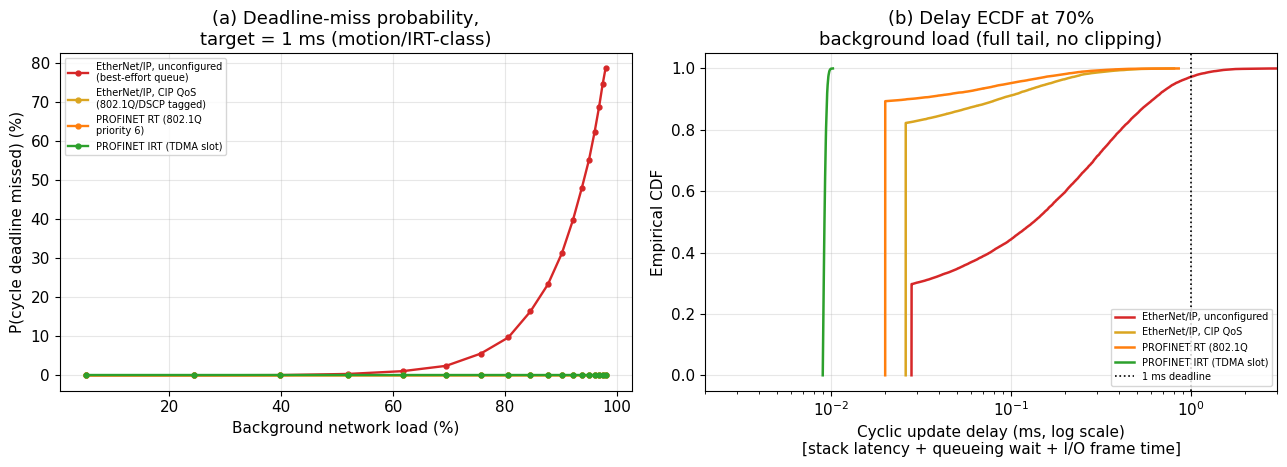

In [12]:
# -- Figure 23.3: deadline-miss probability and delay ECDF ---------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
colors = {'EIP_STD':'tab:red', 'EIP_QOS':'goldenrod', 'PN_RT':'tab:orange', 'PN_IRT':'tab:green'}
names  = {'EIP_STD':'EtherNet/IP, unconfigured\n(best-effort queue)',
          'EIP_QOS':'EtherNet/IP, CIP QoS\n(802.1Q/DSCP tagged)',
          'PN_RT':'PROFINET RT (802.1Q\npriority 6)',
          'PN_IRT':'PROFINET IRT (TDMA slot)'}

ax = axes[0]
Tc_label = '1 ms (motion/IRT-class)'
for cls in classes:
    ax.plot(loads*100, results[cls][Tc_label]*100, color=colors[cls], marker='o', ms=3.5, label=names[cls])
ax.set_xlabel('Background network load (%)')
ax.set_ylabel('P(cycle deadline missed) (%)')
ax.set_title(f'(a) Deadline-miss probability,\ntarget = {Tc_label}')
ax.legend(fontsize=7)

ax = axes[1]
# An empirical CDF on a log-x axis shows the full tail honestly, rather
# than a fixed-range histogram or a clip() that would pile up long-tail
# values into an artificial spike at the axis edge and hide exactly the
# long-tail behaviour the surrounding text discusses.
for cls in classes:
    sorted_vals = np.sort(snap[cls])
    ecdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax.plot(sorted_vals, ecdf, color=colors[cls], label=names[cls].split('\n')[0], lw=1.8)
ax.axvline(1.0, color='black', ls=':', lw=1.2, label='1 ms deadline')
ax.set_xscale('log')
ax.set_xlim(2e-3, 3)
ax.set_xlabel('Cyclic update delay (ms, log scale)\n[stack latency + queueing wait + I/O frame time]')
ax.set_ylabel('Empirical CDF')
ax.set_title('(b) Delay ECDF at 70%\nbackground load (full tail, no clipping)')
ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

### Analysis

**Figure 23.3(a)** shows four qualitatively different responses to
rising background traffic. Unconfigured EtherNet/IP tracks the network
load directly: below roughly 60% load, a 1 ms cycle target is
essentially always met, but as the segment approaches saturation the
miss probability rises steeply — past 30% by 90% load in this model.
Enabling the CIP QoS Object changes this dramatically even with a
comparatively conservative effective-load factor (0.25): its miss
probability stays near the simulation's noise floor across the entire
tested range. PROFINET RT, with a smaller assumed effective-load
factor (0.15), performs similarly well; PROFINET IRT, with no queueing
contention modelled at all, is more stable still.

The gap between "EtherNet/IP, unconfigured" and "EtherNet/IP, with CIP
QoS" is the most practically important result in this exercise: **it is
the same physical network and the same protocol family**, differing
only in whether an optional priority-tagging object — not guaranteed to
be active unless specifically configured or required by the applicable
CIP profile — has been turned on. A network that "PROFINET does better
than EtherNet/IP" at deadline reliability may really be observing a
configuration choice, not an inherent protocol limitation.

**Figure 23.3(b)**, a snapshot at 70% background load shown as an
empirical CDF on a log axis (chosen specifically so the long tail is
visible rather than compressed or clipped into an edge artefact), shows
the mechanism directly: unconfigured EtherNet/IP's curve climbs slowly
and crosses the 1 ms deadline line still well short of 1.0, meaning a
non-trivial fraction of cycles genuinely exceed the deadline, while the
three priority-aware configurations' curves rise steeply and reach 1.0
far to the left of the 1 ms line — PROFINET IRT so far to the left that
its entire distribution sits within a fraction of a millisecond of its
fixed hardware latency.

The 0.15/0.25 effective-load factors used for PROFINET RT and CIP QoS
are explicitly illustrative parameters, not measured constants — the
sensitivity check above shows the qualitative conclusion (priority
queueing keeps 1 ms miss probability near zero at 90% background load)
holds across a 6-fold range of that factor (0.05 to 0.30), even though
the exact miss percentage naturally shifts with it.

> **Key takeaway.** Average delay is a poor predictor of deadline-miss
> risk: unconfigured EtherNet/IP's *median* delay stays low even at
> moderate load, but the *tail* of its best-effort queueing wait grows
> fastest as the network approaches saturation, and that tail is exactly
> what a tight cyclic deadline is sensitive to. Priority queueing —
> whether PROFINET RT's 802.1Q tagging or EtherNet/IP's own CIP QoS
> Object — removes most of that tail risk; TDMA slot reservation
> (PROFINET IRT) removes essentially all of it, at successively higher
> configuration and hardware cost.

### Challenge tasks

1. Rerun the deadline-miss analysis for the 4 ms and 32 ms cycle
   targets. At what background load does unconfigured EtherNet/IP's
   miss probability for the 32 ms target first exceed 1%? Is any form
   of priority queueing necessary at that target?
2. `IO_FRAME_TIME` was fixed at 8 µs for all four classes. PROFINET IRT
   cyclic frames are often smaller than best-effort background frames;
   recompute PROFINET IRT's delay distribution with a shorter
   `IO_FRAME_TIME` (e.g. 3 µs) and quantify how much of its advantage
   over PROFINET RT comes from avoiding queueing versus from a smaller
   frame.
3. The CIP-QoS effective-load factor (0.25) was chosen to sit between
   PROFINET RT's (0.15) and unconfigured EtherNet/IP's (1.0). Research
   ODVA's actual recommended CIP traffic-priority classes (there are
   four) and design a more detailed model with one effective-load
   factor per class instead of a single aggregate value.
4. The service time was fixed at a value representative of 100 Mbps
   Ethernet. Recompute Figure 23.3(a) for a Gigabit Ethernet segment
   (roughly 10x smaller service time) — does unconfigured EtherNet/IP
   become viable for the 1 ms target at realistic loads, or does the
   queueing-delay *shape*, not just its scale, remain the limiting
   factor?

---
## Exercise 23.4 — Wired vs. Wireless for Industrial IoT: A Quantitative Decision Framework

### Background

Every protocol examined so far in this chapter assumes a wired network
already exists. In practice, a large share of IIoT retrofit projects —
adding condition-monitoring sensors to an existing plant — face a
genuine choice between extending a wired Modbus/PROFINET backbone and
deploying a wireless overlay instead. This closing exercise is a
deliberate **cross-chapter, system-level synthesis**: Chapters 17 and 20
covered wireless range, energy budgets, and technology selection in
general; what is new here is a **total-cost-of-ownership (TCO) and
reliability decision framework** applied specifically to the
wired-versus-wireless retrofit choice for an *existing wired industrial*
network — a question those earlier, wireless-focused chapters did not
address, and the natural closing question for a chapter about wired
industrial protocols.

All cost figures below are **stated, illustrative parameters** — cable,
labour, and hardware costs vary widely by region, contractor, and
vendor — chosen to be representative in order, not to be read as a
market-price citation. Wired cost scales with node count and cable run
with no significant recurring cost. Wireless cost front-loads a
per-node radio cost and a shared gateway, then accrues a **recurring**
battery-replacement cost over the planning horizon — a replacement due
exactly at the end of the horizon provides no further service within
it and is therefore excluded from the count. Wireless reliability is
modelled with a logistic packet-delivery-ratio (PDR) fall-off with
distance, improved by link-layer retries; the retry model assumes
statistically **independent** retry attempts, which will overstate the
benefit of retries under correlated interference (a persistent jammer,
sustained multipath fading, or a fixed obstruction) rather than
independent, transient noise.

In [13]:
# -- Exercise 23.4: total-cost-of-ownership model -------------------------
PARAMS = dict(
    cable_cost_per_m       = 9.0,
    wired_switch_port_cost = 25.0,
    wireless_node_cost     = 140.0,
    gateway_cost           = 900.0,
    nodes_per_gateway      = 50,
    battery_cost           = 18.0,
    battery_years          = 2.5,
    truck_roll_cost        = 35.0,
    horizon_years          = 10,
)

def wired_tco(M, mean_distance_m, p):
    cable = M * mean_distance_m * p['cable_cost_per_m']
    switching = M * p['wired_switch_port_cost']
    return cable + switching

def wireless_tco(M, p):
    nodes = M * p['wireless_node_cost']
    gateways = np.ceil(M / p['nodes_per_gateway']) * p['gateway_cost']
    # A replacement due exactly at the horizon boundary is excluded: ceil(H/T)-1
    # counts only replacements that occur strictly within the operating horizon.
    replacements = int(np.ceil(p['horizon_years'] / p['battery_years'])) - 1
    recurring = M * replacements * (p['battery_cost'] + p['truck_roll_cost'])
    return nodes + gateways + recurring, replacements

wtco50, reps = wireless_tco(50, PARAMS)
print(f"Battery replacements over {PARAMS['horizon_years']}-yr horizon "
      f"@ {PARAMS['battery_years']}-yr interval: {reps}")
print(f"10-yr TCO @ 50 nodes, 60 m mean run: "
      f"wired = ${wired_tco(50,60,PARAMS):,.0f}   wireless = ${wtco50:,.0f}")

M_grid = np.arange(5, 155, 5)
D_grid = np.arange(5, 205, 5)
diff = np.zeros((len(D_grid), len(M_grid)))
for i, d in enumerate(D_grid):
    for j, M in enumerate(M_grid):
        wt, _ = wireless_tco(M, PARAMS)
        diff[i, j] = wt - wired_tco(M, d, PARAMS)

def breakeven_distance(M, p):
    '''Closed-form break-even mean cable run at fixed node count M.'''
    wt, _ = wireless_tco(M, p)
    return (wt - M*p['wired_switch_port_cost']) / (M*p['cable_cost_per_m'])

d_be_40 = breakeven_distance(40, PARAMS)
print(f"\nAnalytical break-even mean cable run at M=40 nodes: {d_be_40:.1f} m "
      f"(a 5-m evaluation grid resolves this only to the nearest 5 m bracket)")

Battery replacements over 10-yr horizon @ 2.5-yr interval: 3
10-yr TCO @ 50 nodes, 60 m mean run: wired = $28,250   wireless = $15,850

Analytical break-even mean cable run at M=40 nodes: 32.9 m (a 5-m evaluation grid resolves this only to the nearest 5 m bracket)


In [14]:
# -- Exercise 23.4: reliability model, with a clearly-flagged edge case ---
def pdr_single(d, d0=150.0, k=25.0):
    return 1.0/(1.0+np.exp((d-d0)/k))

def pdr_with_retries(d, R):
    '''Assumes independent retry attempts -- see Background caveat above.'''
    p = pdr_single(d)
    return 1 - (1-p)**(R+1)

WIRED_PDR = 0.999995
target_pdr = 0.9999
PRACTICAL_RETRY_LIMIT = 15   # a labelled threshold, not a silent cutoff: retry counts
                              # above this are flagged as impractical for latency/energy
                              # reasons, but the true minimum is still computed exactly.

def retries_needed_exact(d, target=target_pdr):
    '''Closed-form minimum R such that (1-p)^(R+1) <= 1-target, i.e. no loop/cutoff bug:
    R_min = ceil( log(1-target) / log(1-p) ) - 1.'''
    p = pdr_single(d)
    if p <= 0:
        return None
    R_min = int(np.ceil(np.log(1-target) / np.log(1-p))) - 1
    return max(R_min, 0)

d_range = np.linspace(10, 250, 200)
retries_list = [0, 1, 2, 3, 4]
pdr_curves = {R: pdr_with_retries(d_range, R) for R in retries_list}

for d in [100, 150, 180, 220]:
    r = retries_needed_exact(d)
    flag = "" if r <= PRACTICAL_RETRY_LIMIT else f"  (exceeds the {PRACTICAL_RETRY_LIMIT}-retry practicality threshold)"
    print(f"Retries for PDR >= {target_pdr*100:.2f}% at {d} m: {r} (total attempts = {r+1}){flag}")

Retries for PDR >= 99.99% at 100 m: 4 (total attempts = 5)
Retries for PDR >= 99.99% at 150 m: 13 (total attempts = 14)
Retries for PDR >= 99.99% at 180 m: 34 (total attempts = 35)  (exceeds the 15-retry practicality threshold)
Retries for PDR >= 99.99% at 220 m: 156 (total attempts = 157)  (exceeds the 15-retry practicality threshold)


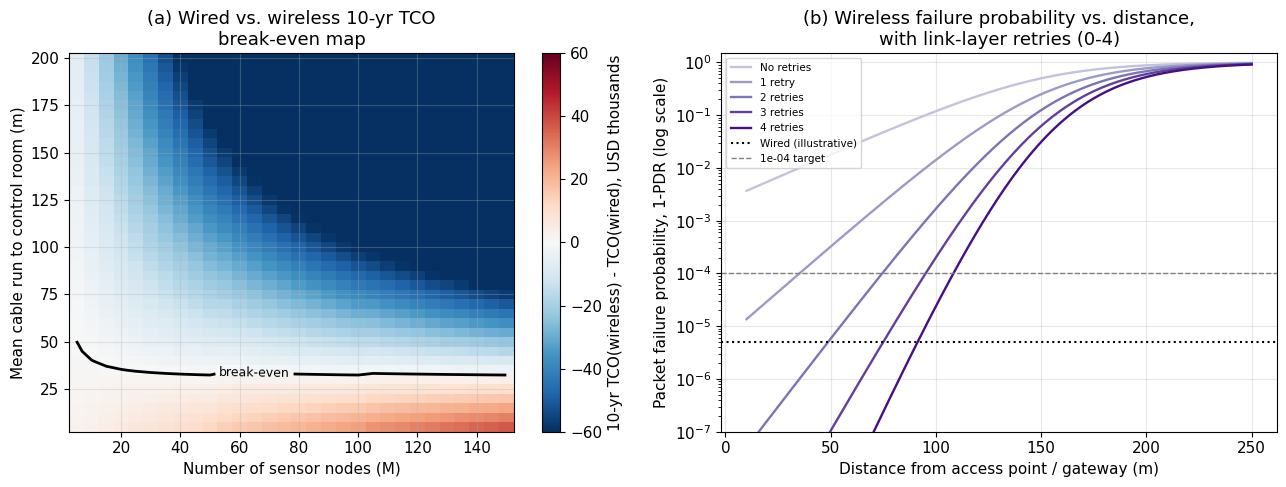

In [15]:
# -- Figure 23.4: break-even map and reliability-vs-distance curves ------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

ax = axes[0]
im = ax.pcolormesh(M_grid, D_grid, diff/1000, cmap='RdBu_r', shading='auto', vmin=-60, vmax=60)
cs = ax.contour(M_grid, D_grid, diff, levels=[0], colors='k', linewidths=2)
ax.clabel(cs, fmt={0: 'break-even'}, fontsize=9)
cb = plt.colorbar(im, ax=ax)
cb.set_label('10-yr TCO(wireless) - TCO(wired), USD thousands')
ax.set_xlabel('Number of sensor nodes (M)')
ax.set_ylabel('Mean cable run to control room (m)')
ax.set_title('(a) Wired vs. wireless 10-yr TCO\nbreak-even map')

ax = axes[1]
# Plotting 1-PDR (failure probability) on a log axis, rather than PDR(%)
# on a linear 0-100% axis, is what actually makes 99.99% / 99.9939% /
# 99.9995% visually distinguishable -- on a linear percentage axis they
# are indistinguishable, even though they differ by orders of magnitude
# in exactly the quantity (failure rate) that matters operationally.
colors_r = plt.cm.Purples(np.linspace(0.35, 0.95, len(retries_list)))
for R, c in zip(retries_list, colors_r):
    label = 'No retries' if R == 0 else (f'{R} retry' if R == 1 else f'{R} retries')
    failure_prob = np.clip(1 - pdr_curves[R], 1e-8, 1.0)
    ax.plot(d_range, failure_prob, color=c, label=label)
ax.axhline(1-WIRED_PDR, color='k', ls=':', lw=1.5, label='Wired (illustrative)')
ax.axhline(1-target_pdr, color='gray', ls='--', lw=1, label=f'{(1-target_pdr):.0e} target')
ax.set_xlabel('Distance from access point / gateway (m)')
ax.set_ylabel('Packet failure probability, 1-PDR (log scale)')
ax.set_title('(b) Wireless failure probability vs. distance,\nwith link-layer retries (0-4)')
ax.legend(fontsize=7.5, loc='upper left')
ax.set_yscale('log')
ax.set_ylim(1e-7, 1.5)

plt.tight_layout()
plt.show()

### Analysis

**Figure 23.4(a)** shows a clean break-even boundary running diagonally
across the (node count, cable-run) plane. Below and to the right of it —
short cable runs, or too few nodes to amortise the wireless gateway's
fixed cost — wired is the cheaper option over the 10-year horizon.
Above and to the left — longer runs, where linear cable-and-labour cost
dominates — wireless wins: at 40 nodes, the break-even mean cable run
is approximately 33 m, and beyond it the wireless cost advantage grows
quickly with either additional distance or additional nodes.

**Figure 23.4(b)** adds the piece the cost model alone omits, and the
closed-form retry counts computed above (not a search capped at an
arbitrary bound) show how quickly that benefit runs out. At 100 m,
four retries (five total attempts) reach the 99.99% target comfortably.
At 150 m, the midpoint of the modelled range/interference curve where
the single-attempt delivery probability is exactly 50%, twelve retries
are narrowly *insufficient* (99.988%) while thirteen retries just reach
the target (99.994%) — mathematically reachable, but fourteen total
transmission attempts for one reading may already be unacceptable in
terms of latency and, per the radio-energy-budget reasoning of
Chapter 20, energy. Beyond 150 m the picture changes qualitatively
rather than just quantitatively: 180 m requires 34 retries and 220 m
requires 156, both far outside any practical retry budget, because once
the single-attempt probability drops well below 50%, each additional
retry buys a shrinking fraction of the remaining gap to the target. A
TCO comparison that ignores this curve entirely will systematically
underestimate the true cost, latency, and energy budget of a distant
wireless deployment.

> **Key takeaway.** "Wired vs. wireless" is not a single plant-wide
> decision; it is a per-subsystem break-even calculation that depends on
> node count, cable run, and the reliability the application actually
> needs at the resulting distance. The cost model alone can favour
> wireless strongly at long range and high node count — but only within
> the distance envelope where the reliability model still supports the
> target delivery ratio at a practical number of retries, and only to
> the extent that interference at that distance behaves independently
> from one attempt to the next.

### Challenge tasks

1. Regenerate Figure 23.4(a) for a harsher installation environment
   (e.g. conduit through existing concrete) and describe how the
   break-even boundary shifts.
2. Combine panels (a) and (b) into a single decision function taking
   node count, mean distance, and gateway distance, that returns both
   the cheaper technology and a warning if the wireless option falls
   beyond the range where the target PDR is achievable within, say, 2
   retries.
3. The reliability model assumes independent retries. Modify
   `pdr_with_retries` to model a *correlated* interference source (e.g.
   retries succeed only with some conditional probability given the
   previous attempt failed, rather than the full independent-attempt
   probability) and compare how many retries are needed to reach the
   same target at 100 m under this more pessimistic assumption.
4. Using the radio-energy-budget reasoning from Chapter 20 (Exercise
   20.3), make the battery-replacement interval a function of reporting
   rate rather than a constant, and explore how a less frequent
   reporting schedule changes the wireless TCO curve in Figure
   23.4(a).

---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|--------------------|
| 23.1 | Byte-exact frame-size model and CRC implementation for Modbus RTU/TCP across three protocol-stack levels; serial-vs-Ethernet polling timing | Shows that, in this model, TCP's advantage comes from removing RS-485's shared-medium constraint, not from frame size |
| 23.2 | OPC UA DataValue/Variant sizing; block vs. scattered Modbus reads; report-by-exception with named Subscription parameters | Shows OPC UA's bandwidth advantage depends on both deadband and keep-alive interval together, not deadband alone |
| 23.3 | Exact M/M/1 queueing simulation across four industrial real-time configurations | Separates protocol capability from configuration default: unconfigured vs. QoS-enabled EtherNet/IP differ far more than EtherNet/IP vs. PROFINET RT |
| 23.4 | Total-cost-of-ownership and PDR-vs-distance decision model | Turns a wired-industrial-network retrofit's "wired vs. wireless" question into a break-even calculation that accounts for both cost and reliability |

All four exercises build toward the same conclusion from different
angles: the "best" wired industrial protocol, encoding, or medium is
never universal — it depends on the specific update rate, distance,
node count, and configuration choices a given subsystem actually uses,
and getting the comparison right requires being precise about which
protocol-stack level, which named parameters, and which default
settings are actually being compared. That discipline — stating
assumptions explicitly and checking a conclusion against the numbers it
claims to follow from — is the same one Chapter 17 applied to wireless
technology selection and Chapter 26 will apply across the full protocol
landscape covered by this book.